<a href="https://colab.research.google.com/github/helenjoy/tiny-ml/blob/main/motion_detection_tiny_ml_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This step-by-step guide demonstrates an end-to-end TinyML (Edge AI) workflow. You will collect real-world accelerometer data from a smartphone, extract statistical time-series features, train a lightweight Neural Network, convert it into an optimized 8-bit integer (INT8) TensorFlow Lite model, and export it as a C byte array (.h) ready for embedded microcontroller deployment.

Demonstration Overview
# [ Smartphone Sensor ] ──> [ Data Cleaning & Labeling ] ──> [ Sliding Window Feature Extraction ] -> [ Keras Neural Network Training ]-> INT8 Quantization  ->  Microcontroller C Array (.h)

Step 1: Collect Real Accelerometer DataExecute two distinct movement phases on your phone using the sensor app:Open **Phyphox** $\rightarrow$ Select Linear Accelerometer (or Accelerometer).Press Record:Phase 1 (0 to 10 seconds): Keep the phone completely flat and stationary on a table (Label 0: Idle).Phase 2 (10 to 20 seconds): Pick up the phone and shake/move it in your hand (Label 1: Motion).Stop recording, export the session as a CSV file, and download it to your computer.

Step 2: Upload CSV and Format Sensor Channels
Upload your phone's recorded CSV file into Colab and standardize the headers into three spatial dimensions: accel_x, accel_y, and accel_z.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Raw Data.csv to Raw Data.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your uploaded CSV (change filename to match yours)
df_phone = pd.read_csv('Raw Data.csv')

# Inspect the raw column names
print("Original Columns:", df_phone.columns)

# Standardize column names (map Phyphox/Sensor Logger names to X, Y, Z)
# Adjust these string keys depending on your app's exact header names:
column_mapping = {
    'Linear Acceleration x (m/s^2)': 'accel_x',
    'Linear Acceleration y (m/s^2)': 'accel_y',
    'Linear Acceleration z (m/s^2)': 'accel_z'
}
df_phone = df_phone.rename(columns=column_mapping)

# Keep only the X, Y, Z channels
df_clean = df_phone[['accel_x', 'accel_y', 'accel_z']].dropna()

Original Columns: Index(['Time (s)', 'Linear Acceleration x (m/s^2)',
       'Linear Acceleration y (m/s^2)', 'Linear Acceleration z (m/s^2)',
       'Absolute acceleration (m/s^2)'],
      dtype='object')


In [ ]:
import numpy as np

# Split dataset in half (or based on your recording timeline)
midpoint = len(df_clean) // 2

labels = np.zeros(len(df_clean), dtype=int)
labels[midpoint:] = 1  # Mark the second half as 'Motion' (1)

df_clean['label'] = labels

Step 3: Visualize Raw Motion Signals
Plot the multi-axis acceleration curves to visually highlight the transition point between resting and active movement.

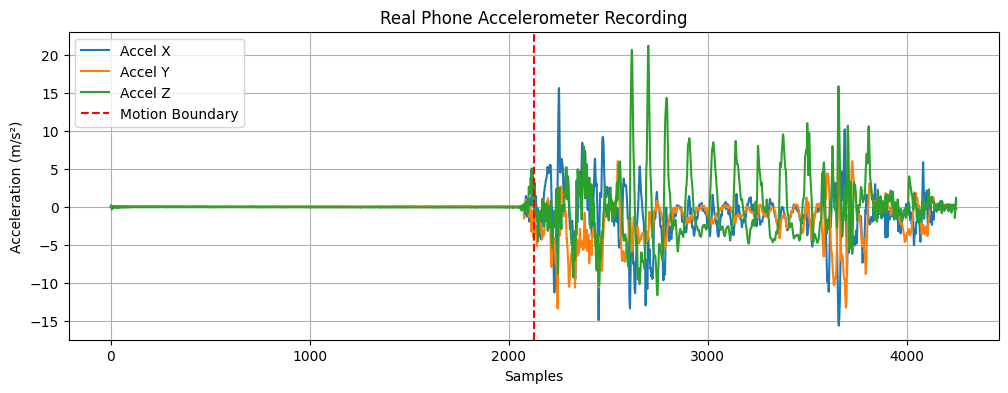

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df_clean['accel_x'], label='Accel X')
plt.plot(df_clean['accel_y'], label='Accel Y')
plt.plot(df_clean['accel_z'], label='Accel Z')
plt.axvline(x=midpoint, color='r', linestyle='--', label='Motion Boundary')
plt.title('Real Phone Accelerometer Recording')
plt.xlabel('Samples')
plt.ylabel('Acceleration (m/s²)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def extract_windows(df, window_size=50, step_size=25):
    windows, labels = [], []
    for i in range(0, len(df) - window_size, step_size):
        win = df.iloc[i:i + window_size]
        features = [
            win['accel_x'].mean(), win['accel_x'].std(),
            win['accel_y'].mean(), win['accel_y'].std(),
            win['accel_z'].mean(), win['accel_z'].std()
        ]
        windows.append(features)
        labels.append(win['label'].iloc[-1])
    return np.array(windows), np.array(labels)

X_real, y_real = extract_windows(df_clean)

print(f"Extracted Dataset Shape from Real Phone: {X_real.shape}")
print(f"Total Prepared Feature Windows: {len(y_real)}")

Extracted Dataset Shape from Real Phone: (169, 6)
Total Prepared Feature Windows: 169


Step 5: Train a Lightweight Neural Network
Construct a compact Multilayer Perceptron (MLP) containing only 14 hidden neurons to minimize footprint for tiny embedded hardware.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Prepare tensors
X_train = X_real.astype(np.float32)
y_train = y_real.astype(np.int32)

# Build lightweight network architecture
model = models.Sequential([
    layers.Input(shape=(6,)),                     # 6 input features
    layers.Dense(8, activation='relu'),            # Hidden Layer 1 (8 neurons)
    layers.Dense(4, activation='relu'),            # Hidden Layer 2 (4 neurons)
    layers.Dense(2, activation='softmax')          # Output Layer (2 target classes)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(X_train, y_train, epochs=35, batch_size=8, verbose=0)
print(f"Training Complete! Final Accuracy: {history.history['accuracy'][-1]:.2%}")

Training Complete! Final Accuracy: 97.04%


Step 6: Quantize Model to Full INT8 (TensorFlow Lite)To run on microcontrollers lacking Floating Point Units (FPUs), compress model weights and activations from 32-bit floats ($FP32$) to 8-bit signed integers ($INT8$).

In [ ]:
# Representative dataset generator used for calibrating INT8 dynamic ranges
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(X_train).batch(1).take(100):
        yield [tf.cast(input_value, tf.float32)]

# Instantiate converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# Strict INT8 enforcement
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert binary model
tflite_quant_model = converter.convert()

# Write .tflite binary file to disk
with open('phone_motion_model.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print(f"Quantized TFLite Model Size: {len(tflite_quant_model)} bytes (~{round(len(tflite_quant_model)/1024, 2)} KB)")

Saved artifact at '/tmp/tmpl_a96sr1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  136623448882640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136623448882448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136623448883024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136623448882832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136623448881872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136623443870928: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized TFLite Model Size: 2872 bytes (~2.8 KB)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Step 7: Simulate Local Edge Inference
Validate the compiled phone_motion_model.tflite model locally inside Colab using tf.lite.Interpreter prior to hardware deployment.

In [ ]:
# Instantiate TFLite Interpreter
interpreter = tf.lite.Interpreter(model_path='phone_motion_model.tflite')
interpreter.allocate_tensors()

# Obtain tensor index mappings
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Select test sample (First sample in training set)
test_sample = X_train[0:1]

# Quantize float inputs to signed INT8 values using scale and zero-point parameters
scale, zero_point = input_details[0]['quantization']
quantized_input = (test_sample / scale + zero_point).astype(np.int8)

# Execute inference
interpreter.set_tensor(input_details[0]['index'], quantized_input)
interpreter.invoke()

# Extract prediction
raw_output = interpreter.get_tensor(output_details[0]['index'])
predicted_class = np.argmax(raw_output)

print("\n--- Local Edge Inference Verification ---")
print(f"Quantized Input Value: {quantized_input}")
print(f"Raw Output Tensor: {raw_output}")
print(f"Predicted Class: {predicted_class} ({'Idle' if predicted_class == 0 else 'Motion'})")


--- Local Edge Inference Verification ---
Quantized Input Value: [[-5 -5 -6 -5 -7 -4]]
Raw Output Tensor: [[ 42 -42]]
Predicted Class: 0 (Idle)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Step 8: Export Model to C Byte Array (.h)
Convert the binary .tflite file into an exported C header array. This array can be directly included in C/C++ firmware projects compiled with TensorFlow Lite for Microcontrollers (TFLM) on platforms like ESP32, Arduino, or STM32.

In [ ]:
!apt-get update
!apt-get install -y vim-common

# Generate C source header file using xxd command
!xxd -i phone_motion_model.tflite > phone_motion_model.h
print("Successfully generated C header file: 'phone_motion_model.h'\n")

# Preview header content
!head -n 20 phone_motion_model.h

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu noble InRelease
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
vim-common is already the newest version (2:9.1.0016-1ubuntu7.20).
0 upgraded, 0 newly installed, 0 to remove and 44 not upgraded.
/bin/bash: line 1: xxd: command not fou